# Vision-Assisted Orbit Correction

In Phase 1, we built a PINN that learns orbital motion purely from Newton's law of gravitation. It works well — but only if the physics we told it about is the *whole* story.

Real satellites experience forces a simple two-body model doesn't capture: atmospheric drag, solar radiation pressure, gravitational quirks from other bodies, or unplanned maneuvers. When that happens, a PINN trained on ideal physics will confidently predict a trajectory that drifts further and further from where the satellite actually is.

This is where **observation** comes in. Real orbit-tracking systems don't rely on physics models alone — they continuously correct their predictions using data from telescopes, radar, or other sensors. In this notebook, we build a simplified version of that idea:

1. Introduce a small, realistic disturbance so the true orbit no longer perfectly matches our PINN's physics.
2. Simulate synthetic "telescope images" of the satellite at its true (disturbed) position.
3. Build a small computer vision model that detects the satellite's position from these images.
4. Use those vision-based observations to correct the PINN's drifting prediction.
5. Compare all three trajectories: the true orbit, the PINN-only prediction, and the vision-corrected prediction.

![Vision-assisted PINN pipeline](../images/pinn_vision_pipeline.png)

In [16]:
# Core numerical arrays and math operations
import numpy as np

# Neural network framework — reloading the PINN, building the CNN
import torch
import torch.nn as nn

# Static plots (orbits, images, comparisons)
import matplotlib.pyplot as plt

# Classical numerical ODE solver — regenerating ground truth with a disturbance
from scipy.integrate import solve_ivp

# For reproducibility
np.random.seed(42)
torch.manual_seed(42)

# Use GPU if available, otherwise CPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cpu


In [17]:
class PINN(nn.Module):
    """
    Same architecture as Phase 1 — must match exactly to load the saved weights.
    Maps time -> predicted (x, y) position.
    """
    def __init__(self, hidden_dim=64, n_hidden_layers=4):
        super().__init__()
        layers = [nn.Linear(1, hidden_dim), nn.Tanh()]
        for _ in range(n_hidden_layers - 1):
            layers += [nn.Linear(hidden_dim, hidden_dim), nn.Tanh()]
        layers += [nn.Linear(hidden_dim, 2)]
        self.net = nn.Sequential(*layers)

    def forward(self, t):
        return self.net(t)


pinn = PINN(hidden_dim=64, n_hidden_layers=4).to(device)
pinn.load_state_dict(torch.load("pinn_weights.pth", map_location=device))
pinn.eval()
print("Loaded pre-trained PINN from Phase 1.")

Loaded pre-trained PINN from Phase 1.


## Recreating the Phase 1 Baseline

Since this is a separate notebook, we need to regenerate the pieces from Phase 1 that we'll build on here: the clean two-body simulation (our undisturbed "ground truth"), and the trained PINN's prediction over that same time range. Nothing here is new — it's the same code and the same trained weights from Notebook 1, just re-run here so this notebook is self-contained.

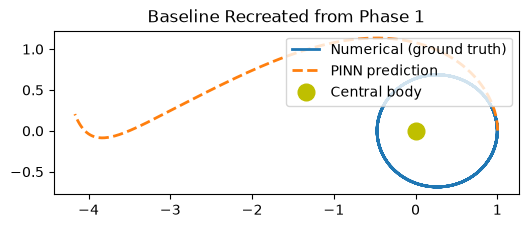

In [18]:
# --- Shared physics constant ---
GM = 1.0

def two_body_dynamics(t, state):
    """Clean two-body gravity, no disturbances. state = [x, y, vx, vy]"""
    x, y, vx, vy = state
    r = np.sqrt(x**2 + y**2)
    ax = -GM * x / r**3
    ay = -GM * y / r**3
    return [vx, vy, ax, ay]

# --- Same initial conditions and time range as Phase 1 ---
initial_state = [1.0, 0.0, 0.0, 0.8]  # [x0, y0, vx0, vy0]
t_span = (0, 20)
t_eval = np.linspace(*t_span, 1000)

# --- Regenerate the clean "ground truth" orbit ---
solution = solve_ivp(
    two_body_dynamics,
    t_span,
    initial_state,
    t_eval=t_eval,
    method="DOP853",
    rtol=1e-10,
    atol=1e-10
)
x_true, y_true = solution.y[0], solution.y[1]

# --- Regenerate the PINN's prediction using the loaded weights ---
t_test = torch.tensor(t_eval, dtype=torch.float32, device=device).reshape(-1, 1)
with torch.no_grad():
    r_pred = pinn(t_test).cpu().numpy()
x_pinn, y_pinn = r_pred[:, 0], r_pred[:, 1]

# Quick sanity check: should match the Phase 1 trajectory overlay
plt.figure(figsize=(6, 6))
plt.plot(x_true, y_true, label="Numerical (ground truth)", linewidth=2)
plt.plot(x_pinn, y_pinn, '--', label="PINN prediction", linewidth=2)
plt.plot(0, 0, "yo", markersize=12, label="Central body")
plt.gca().set_aspect("equal")
plt.legend(loc="upper right")
plt.title("Baseline Recreated from Phase 1")
plt.show()

## Step 1: Introducing a Disturbance

Our Phase 1 PINN learned pure two-body gravity — no other forces. But real satellites, especially in low orbits, experience **atmospheric drag**: a small force that opposes velocity and slowly bleeds energy from the orbit, causing it to decay over time.

We'll simulate this by adding a simple drag term to our equations of motion:

$$
\vec a_{\text{drag}} = -k \, |\vec v| \, \vec v
$$

In plain terms: drag pushes back against the satellite's motion, and it gets stronger the faster the satellite moves — similar to how wind resistance increases with speed.

We'll generate a **new "true" orbit** using this disturbed physics. Critically, our already-trained PINN knows nothing about drag — it will keep predicting the clean, undisturbed orbit from Phase 1. This mismatch is exactly what we want: a case where pure physics prediction fails, and observation becomes necessary.

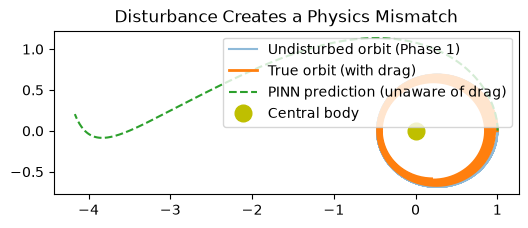

In [19]:
# Drag coefficient — small enough to cause gradual, visible decay
k_drag = 0.003

def disturbed_dynamics(t, state):
    """
    Same as two_body_dynamics, but with an added atmospheric drag term.
    state = [x, y, vx, vy]
    """
    x, y, vx, vy = state
    r = np.sqrt(x**2 + y**2)
    v = np.sqrt(vx**2 + vy**2)

    # Gravitational acceleration (same as before)
    ax_grav = -GM * x / r**3
    ay_grav = -GM * y / r**3

    # Drag acceleration — opposes velocity, grows with speed
    ax_drag = -k_drag * v * vx
    ay_drag = -k_drag * v * vy

    ax = ax_grav + ax_drag
    ay = ay_grav + ay_drag

    return [vx, vy, ax, ay]

# Solve using the SAME initial conditions and time span as Phase 1,
# so we can directly compare disturbed vs. undisturbed motion
solution_disturbed = solve_ivp(
    disturbed_dynamics,
    t_span,
    initial_state,
    t_eval=t_eval,
    method="DOP853",
    rtol=1e-10,
    atol=1e-10
)

x_disturbed, y_disturbed = solution_disturbed.y[0], solution_disturbed.y[1]

# Compare: clean orbit vs. disturbed (true) orbit vs. PINN's (uninformed) prediction
plt.figure(figsize=(6, 6))
plt.plot(x_true, y_true, label="Undisturbed orbit (Phase 1)", alpha=0.5)
plt.plot(x_disturbed, y_disturbed, label="True orbit (with drag)", linewidth=2)
plt.plot(x_pinn, y_pinn, '--', label="PINN prediction (unaware of drag)")
plt.plot(0, 0, "yo", markersize=12, label="Central body")
plt.gca().set_aspect("equal")
plt.legend(loc="upper right")
plt.title("Disturbance Creates a Physics Mismatch")
plt.show()

### What's happening here

The faded line is the orbit we'd expect if gravity were the only force acting on the satellite. The solid line is what actually happens once we add drag — a force that slowly saps the satellite's energy, causing its orbit to shrink inward over time. The dashed line is our PINN's prediction, which still thinks the faded, undisturbed orbit is correct, since it was only ever taught pure gravity.

The gap between the dashed line and the solid line is the problem this notebook exists to solve: the PINN's guess is drifting away from reality.

## Step 2: Simulating Telescope Observations

Real orbit-tracking systems get their observations from telescopes or radar, not from a clean (x, y) coordinate. To keep things realistic, we won't hand our vision model perfect position data — instead, we'll generate **synthetic images**: small grayscale "telescope frames" showing the satellite as a bright dot against a dark, slightly noisy background, placed at its true (disturbed) position.

This mimics the real pipeline: a telescope captures a picture, and only *then* does something (in our case, a neural network) have to figure out where the satellite actually is in that image.

We'll

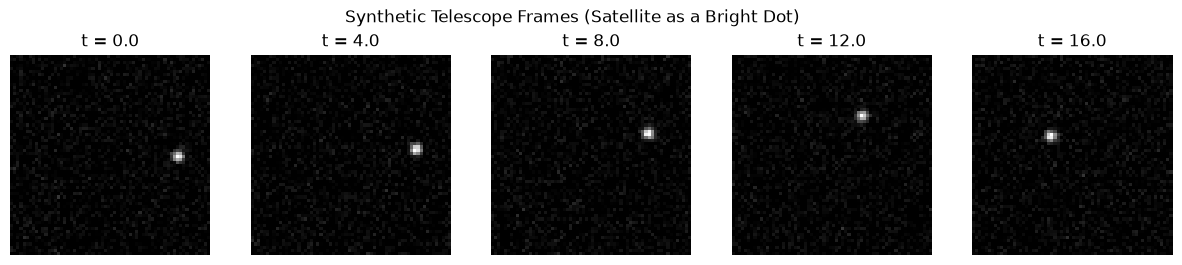

In [20]:
image_size = 64  # 64x64 pixel "telescope frames"

# Our orbit roughly spans [-1.5, 1.5] in both x and y — map that range to pixel coordinates
world_extent = 1.5

def world_to_pixel(x, y, image_size=image_size, extent=world_extent):
    """Convert real-world (x, y) coordinates to (row, col) pixel coordinates."""
    px = ((x + extent) / (2 * extent)) * image_size
    py = ((extent - y) / (2 * extent)) * image_size  # flip y: image rows go top-to-bottom
    return px, py

def generate_telescope_image(x, y, image_size=image_size, noise_level=0.05, dot_sigma=1.2):
    """
    Renders a synthetic telescope image: a bright Gaussian 'dot' at the satellite's
    true position, on a noisy dark background.
    """
    px, py = world_to_pixel(x, y, image_size)

    # Pixel grid
    xx, yy = np.meshgrid(np.arange(image_size), np.arange(image_size))

    # Bright Gaussian blob centered at (px, py) -- mimics a point source of light
    image = np.exp(-((xx - px)**2 + (yy - py)**2) / (2 * dot_sigma**2))

    # Background sensor noise
    image += np.random.normal(0, noise_level, size=image.shape)
    image = np.clip(image, 0, 1)

    return image, (px, py)

# Quick look at a few sample frames across the disturbed orbit
sample_indices = [0, 200, 400, 600, 800]

fig, axes = plt.subplots(1, len(sample_indices), figsize=(15, 3))
for ax, idx in zip(axes, sample_indices):
    img, (px, py) = generate_telescope_image(x_disturbed[idx], y_disturbed[idx])
    ax.imshow(img, cmap="gray")
    ax.set_title(f"t = {t_eval[idx]:.1f}")
    ax.axis("off")
plt.suptitle("Synthetic Telescope Frames (Satellite as a Bright Dot)")
plt.show()

### What's happening here

Each small image is a stand-in for a real photo a telescope might take of the satellite at a specific moment in time. The bright dot is the satellite; everything else is background noise, mimicking the graininess of a real camera sensor. As the satellite moves along its orbit, the dot moves to a different spot in each image — this is the raw information a tracking system would actually have to work with, rather than a clean set of coordinates handed to it directly.

## Step 3: Detecting the Satellite in an Image

Now we need a model that looks at one of these telescope frames and answers: *where is the satellite, in pixel coordinates?*

This is a classic **regression** task for a Convolutional Neural Network (CNN): instead of classifying the image into a category, the network outputs two continuous numbers — the (row, column) pixel location of the bright dot.

The architecture is intentionally small. Our images are simple (a single blurred dot on a mostly empty background), so a deep network isn't necessary — a few convolutional layers to detect the dot's local pattern, followed by a couple of fully-connected layers to regress its coordinates, is enough.


![How the CNN detector reads an image](../images/cnn_architecture.png)

In [ ]:
class SatelliteDetector(nn.Module):
    """
    Small CNN that takes a (1, image_size, image_size) grayscale image
    and regresses the satellite's (px, py) pixel position.
    """
    def __init__(self, image_size=64):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(1, 16, kernel_size=3, padding=1), nn.ReLU(), nn.MaxPool2d(2),  # -> 16 x 32 x 32
            nn.Conv2d(16, 32, kernel_size=3, padding=1), nn.ReLU(), nn.MaxPool2d(2), # -> 32 x 16 x 16
        )
        flattened_size = 32 * (image_size // 4) * (image_size // 4)
        self.fc = nn.Sequential(
            nn.Linear(flattened_size, 64),
            nn.ReLU(),
            nn.Linear(64, 2)  # output: (px, py)
        )

    def forward(self, x):
        x = self.conv(x)
        x = x.flatten(start_dim=1)
        return self.fc(x)


detector = SatelliteDetector(image_size=image_size).to(device)
print(detector)


SatelliteDetector(
  (conv): Sequential(
    (0): Conv2d(1, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (fc): Sequential(
    (0): Linear(in_features=8192, out_features=64, bias=True)
    (1): ReLU()
    (2): Linear(in_features=64, out_features=2, bias=True)
  )
)
zsh:1: bad pattern: [How


## Step 4: Training the Detector

To train the CNN, we need a dataset of (image, true pixel position) pairs. Since we're generating these images ourselves, we have the convenient luxury of knowing the exact ground-truth label for every single one — something real telescope data almost never offers so cleanly.

We'll:
1. Generate many synthetic frames from random points along the disturbed orbit (not just the handful we previewed earlier).
2. Record each frame's true pixel position as its label.
3. Train the CNN to minimize the distance between its predicted pixel position and the true one.

This is a much more standard supervised learning setup than the PINN was — here, the network **is** learning from labeled data directly, since "where is the dot in this image" doesn't have a clean physics equation to lean on the way orbital motion does.

Epoch    0 | Pixel MSE loss: 1358.3156
Epoch  200 | Pixel MSE loss: 0.4680
Epoch  400 | Pixel MSE loss: 0.2789
Epoch  600 | Pixel MSE loss: 0.1434
Epoch  800 | Pixel MSE loss: 0.1988
Epoch 1000 | Pixel MSE loss: 0.1468
Epoch 1200 | Pixel MSE loss: 0.0909
Epoch 1400 | Pixel MSE loss: 0.1122
Epoch 1600 | Pixel MSE loss: 0.1229
Epoch 1800 | Pixel MSE loss: 0.0999
Detector training complete.


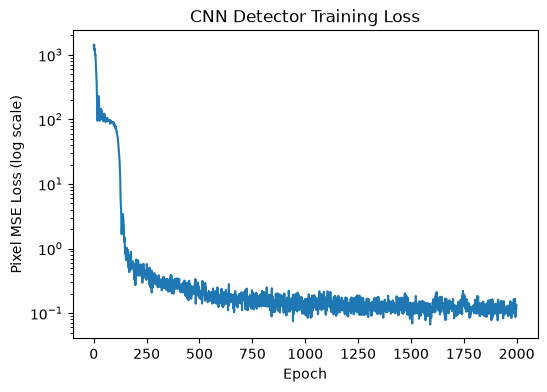

In [22]:
def make_training_batch(batch_size=64):
    """
    Samples random points along the disturbed orbit, renders a telescope
    image for each, and returns (images, pixel_labels) as tensors.
    """
    indices = np.random.randint(0, len(x_disturbed), size=batch_size)

    images = np.zeros((batch_size, 1, image_size, image_size), dtype=np.float32)
    labels = np.zeros((batch_size, 2), dtype=np.float32)

    for i, idx in enumerate(indices):
        img, (px, py) = generate_telescope_image(x_disturbed[idx], y_disturbed[idx])
        images[i, 0] = img
        labels[i] = [px, py]

    images_t = torch.tensor(images, device=device)
    labels_t = torch.tensor(labels, device=device)
    return images_t, labels_t


# --- Training loop ---
optimizer = torch.optim.Adam(detector.parameters(), lr=1e-3)
n_epochs = 2000
batch_size = 64
detector_loss_history = []

for epoch in range(n_epochs):
    detector.train()
    images, labels = make_training_batch(batch_size)

    optimizer.zero_grad()
    preds = detector(images)
    loss = nn.functional.mse_loss(preds, labels)
    loss.backward()
    optimizer.step()

    detector_loss_history.append(loss.item())

    if epoch % 200 == 0:
        print(f"Epoch {epoch:4d} | Pixel MSE loss: {loss.item():.4f}")

print("Detector training complete.")

# --- Plot training loss ---
plt.figure(figsize=(6, 4))
plt.plot(detector_loss_history)
plt.yscale("log")
plt.xlabel("Epoch")
plt.ylabel("Pixel MSE Loss (log scale)")
plt.title("CNN Detector Training Loss")
plt.show()

### What's happening here

This chart shows the computer vision model learning, over many practice rounds, to find the bright dot in these images. The sharp drop at the start means it quickly figured out the general idea; the flat, low line afterward means it's now consistently accurate and has little left to improve on. In short: the model has learned to reliably "see" where the satellite is in a photo.

## Step 5: From Pixels Back to the Real World

The CNN gives us a position in **pixel space** — but the PINN operates in **real-world coordinates** (the same (x, y) units as our orbital simulation). To fuse these two together, we need to convert one into the other.

This is a simplified version of what's called **camera geometry** in real computer vision systems: a mapping between where something appears in an image and where it actually is in physical space. Since we defined exactly how we rendered these images (`world_to_pixel` in Step 2), we can simply invert that same formula to go the other direction.

![Converting pixel coordinates to real-world coordinates](../images/camera_geometry.png)

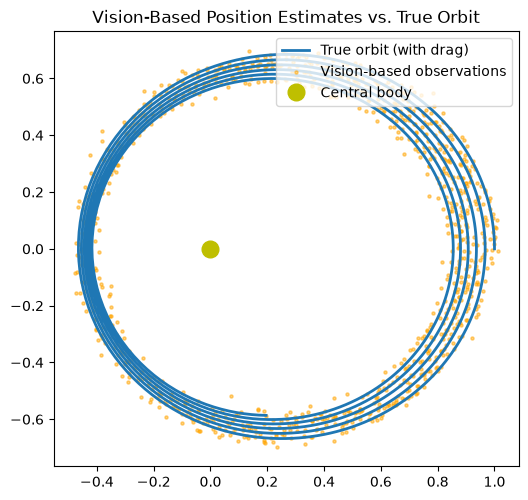

In [23]:
def pixel_to_world(px, py, image_size=image_size, extent=world_extent):
    """Inverse of world_to_pixel: converts pixel coordinates back to real-world (x, y)."""
    x = (px / image_size) * (2 * extent) - extent
    y = extent - (py / image_size) * (2 * extent)
    return x, y


# --- Run the trained detector across the full disturbed orbit ---
detector.eval()

vision_x, vision_y = [], []

with torch.no_grad():
    for i in range(len(x_disturbed)):
        img, _ = generate_telescope_image(x_disturbed[i], y_disturbed[i])
        img_t = torch.tensor(img, dtype=torch.float32, device=device).unsqueeze(0).unsqueeze(0)
        px_pred, py_pred = detector(img_t)[0].cpu().numpy()
        x_obs, y_obs = pixel_to_world(px_pred, py_pred)
        vision_x.append(x_obs)
        vision_y.append(y_obs)

vision_x = np.array(vision_x)
vision_y = np.array(vision_y)

# --- Compare vision-based observations against the true disturbed orbit ---
plt.figure(figsize=(6, 6))
plt.plot(x_disturbed, y_disturbed, label="True orbit (with drag)", linewidth=2)
plt.scatter(vision_x, vision_y, s=5, color="orange", label="Vision-based observations", alpha=0.5)
plt.plot(0, 0, "yo", markersize=12, label="Central body")
plt.gca().set_aspect("equal")
plt.legend(loc="upper right")
plt.title("Vision-Based Position Estimates vs. True Orbit")
plt.show()

### What's happening here

The solid line is the satellite's real path (the one affected by drag). The orange dots are the vision model's guesses for where the satellite is, based only on looking at the synthetic photos — translated from "a spot in an image" back into real-world coordinates. The closer these dots hug the line, the better the model is at figuring out the satellite's true position using nothing but pictures, which is exactly what we'll use next to correct the PINN's drifting guess.

## Step 6: Fusing Vision into the PINN's Prediction

Now we bring the two branches together. At each moment, we have two estimates of the satellite's position: the PINN's prediction (confident, but drifting since it doesn't know about drag) and the vision model's observation (grounded in the actual image, but a little noisy). The correction step blends these two into a single, better estimate — pulling the PINN's drifting guess back toward reality using what the vision model actually observed.

![Fusion and correction concept](../images/fusion_correction_concept.png)